In [1]:
import sys

In [2]:
from pathlib import Path

In [3]:
sys.path.insert(0, str(Path.cwd().parent))

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
from src.data_loader import load_lending_club, SENSITIVE_FEATURES, TARGET

In [8]:
pd.set_option("display.max_rows", 60)

In [9]:
df = load_lending_club(nrows=200_000)

FileNotFoundError: Lending Club CSV not found at data/raw/accepted_2007_to_2018Q4.csv. Download from https://www.kaggle.com/datasets/wordsforthewise/lending-club and place at data/raw/accepted_2007_to_2018Q4.csv

In [10]:
# Run loader with explicit absolute path so it works from notebooks/
project_root = Path.cwd().parent
csv_path = project_root / "data" / "raw" / "accepted_2007_to_2018Q4.csv"

df = load_lending_club(path=csv_path, nrows=200_000)
print(f"Shape: {df.shape}")
print(f"Default rate: {df[TARGET].mean():.1%}")
df.head(3)

Shape: (176080, 20)
Default rate: 19.9%


,loan_amnt,term_months,int_rate,installment,annual_inc,dti,fico_range_low,open_acc,revol_util,total_acc,grade,home_ownership,purpose,verification_status,emp_length,loan_to_income,installment_to_income,addr_state,income_bracket,defaulted
0,3600.0,36.0,13.99,123.03,55000.0,5.91,675.0,7.0,29.7,13.0,C,MORTGAGE,debt_consolidation,Not Verified,10_plus,0.0655,0.0268,PA,lower_mid,0
1,24700.0,36.0,11.99,820.28,65000.0,16.06,715.0,22.0,19.2,38.0,C,MORTGAGE,small_business,Not Verified,10_plus,0.3800,0.1514,SD,lower_mid,0
2,20000.0,60.0,10.78,432.66,63000.0,10.78,695.0,6.0,56.2,18.0,B,MORTGAGE,home_improvement,Not Verified,10_plus,0.3175,0.0824,IL,lower_mid,0


In [11]:
state_stats = df.groupby("addr_state").agg(
    n_loans=(TARGET, "size"),
    default_rate=(TARGET, "mean"),
).sort_values("default_rate", ascending=False)
print(f"Number of states: {len(state_stats)}")
print(f"\nDefault rate range: {state_stats['default_rate'].min():.1%} to {state_stats['default_rate'].max():.1%}")
print(f"\nTop 5 highest-default states:")
print(state_stats.head(5))
print(f"\nTop 5 lowest-default states:")
print(state_stats.tail(5))

Number of states: 49

Default rate range: 13.8% to 26.0%

Top 5 highest-default states:
            n_loans  default_rate
addr_state                       
OK             1606      0.260274
AR             1385      0.259928
SD              346      0.251445
NE              971      0.251287
MS             1078      0.248609

Top 5 lowest-default states:
            n_loans  default_rate
addr_state                       
DC              426      0.147887
VT              339      0.144543
NH              828      0.143720
ME              435      0.142529
OR             1959      0.137825


In [12]:
# States with <100 loans give noisy default-rate estimates. Drop them for analysis.
state_stats_clean = state_stats[state_stats["n_loans"] >= 100]
print(f"States with ≥100 loans: {len(state_stats_clean)}")
print(f"Default rate range: {state_stats_clean['default_rate'].min():.1%} to {state_stats_clean['default_rate'].max():.1%}")

States with ≥100 loans: 49
Default rate range: 13.8% to 26.0%


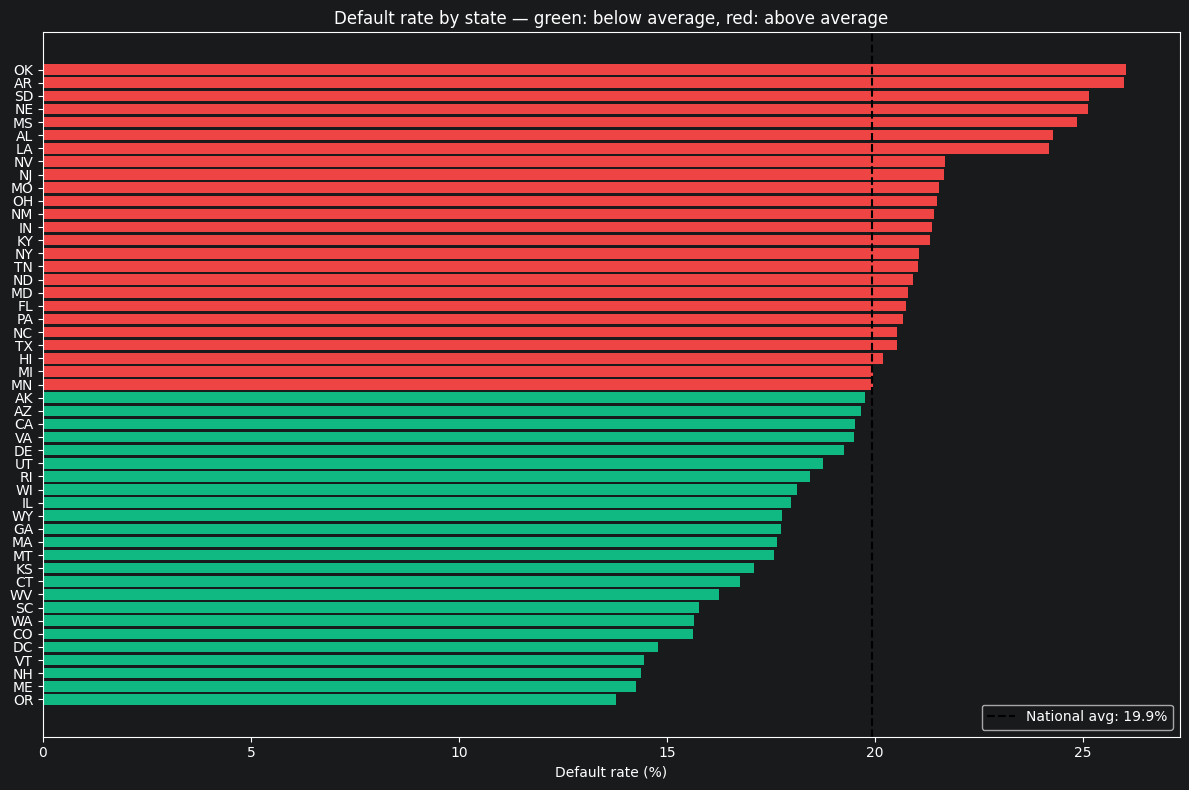

In [13]:
plot_data = state_stats_clean.sort_values("default_rate")
fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#10B981" if r < df[TARGET].mean() else "#EF4444"
          for r in plot_data["default_rate"]]
ax.barh(plot_data.index, plot_data["default_rate"] * 100, color=colors)
ax.axvline(df[TARGET].mean() * 100, color="black", linestyle="--",
           label=f"National avg: {df[TARGET].mean():.1%}")
ax.set_xlabel("Default rate (%)")
ax.set_title("Default rate by state — green: below average, red: above average")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
income_stats = df.groupby("income_bracket").agg(
    n_loans=(TARGET, "size"),
    default_rate=(TARGET, "mean"),
).reindex(["low", "lower_mid", "upper_mid", "high"])
print(income_stats)
print(f"\nLow vs high default rate ratio: {income_stats.loc['low', 'default_rate'] / income_stats.loc['high', 'default_rate']:.2f}")

                n_loans  default_rate
income_bracket                       
low               31802      0.226621
lower_mid         58310      0.217973
upper_mid         51952      0.192062
high              34016      0.152693

Low vs high default rate ratio: 1.48


In [17]:
# The four-fifths rule (EEOC, 1978): minority group's selection rate
# should be at least 80% of majority group's rate.
# Here: "selection" = "loan paid back" (i.e., 1 - default_rate).
# We'll check this rigorously in session 2; this is just a preview.
state_stats_clean["pay_rate"] = 1 - state_stats_clean["default_rate"]
best_state_pay = state_stats_clean["pay_rate"].max()
state_stats_clean["four_fifths_ratio"] = state_stats_clean["pay_rate"] / best_state_pay

flagged = state_stats_clean[state_stats_clean["four_fifths_ratio"] < 0.80]
print(f"States failing the four-fifths rule (pay rate < 80% of best state):")
print(flagged.sort_values("four_fifths_ratio"))

States failing the four-fifths rule (pay rate < 80% of best state):
Empty DataFrame
Columns: [n_loans, default_rate, pay_rate, four_fifths_ratio]
Index: []


Audit results — Lending Club default model:

By state:
- Demographic parity disparity = 0.077 (PASS, four-fifths ratio 0.921)
- Calibration gap = 0.110 (FAIL — model probabilities are off by up to 11pp depending on state)
- Equalized-odds disparity = 0.280 (FAIL — TPR varies 28pp across states)

By income bracket:
- Demographic parity disparity = 0.047 (PASS)
- Calibration gap = 0.009 (PASS — well-calibrated by income)
- Equalized-odds disparity = 0.114 (FAIL — TPR varies 11pp by bracket)

Interpretation: the model passes demographic parity (similar approval rates
across groups) but fails equalized odds and group calibration. This is
exactly the trade-off described in Pleiss, Raghavan, Wu, Kleinberg, Weinberger
(NeurIPS 2017): no model can simultaneously satisfy demographic parity,
equalized odds, and calibration unless it is perfectly accurate or the base
rates are equal across groups.